## Load Data

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load the dataset
data = pd.read_csv('./data/nepse/sector-2021-2026/nepsealpha_export_price_BANKING_2021-01-16_2026-01-16_unadjusted.csv')
# Convert the 'Date' column to datetime format
data['Date'] = pd.to_datetime(data['Date'])
# Set the 'Date' column as the index
data.set_index('Date', inplace=True)
data.sort_index(inplace=True)
# Extract the 'Close' price as a numpy array
# log return 
price = data['Close'].dropna()
log_ret = np.log(price / price.shift(1)).dropna()
r = log_ret.values
T = len(r)


## Exploratory Data Analysis

###  Distributional & Higher-Moment Diagnostics
- **Descriptive Summary Statistics**: Calculate the exact sample mean, variance, skewness, and excess kurtosis of the log returns.

- **Normality Rejecting Tests**: Run formal statistical tests such as the Jarque-Bera and Shapiro-Wilk tests to prove the non-normality of your NEPSE banking data.

- **Empirical Density vs. Gaussian Overlay**: Plot a frequency histogram against a theoretical normal distribution to visually capture the leptokurtic peak and fat tails.

- **Normal Quantile-Quantile (Q-Q) Plot**: Map your sample quantiles against theoretical normal quantiles to isolate exactly where the tail deviations and jump anomalies begin.


       HIGHER-MOMENT STATISTICAL SUMMARY
  Mean (Daily)        : -0.000204 (-0.0204%)
  Variance (Daily)    : 0.000173
  Std. Deviation      : 0.013147 (1.3147%)
  Skewness            : 1.0244
  Excess Kurtosis     : 4.7897
--------------------------------------------------
            FORMAL HYPOTHESIS TESTING
--------------------------------------------------
  Jarque-Bera Test    : Stat = 1316.24, p-value = 1.5188e-286
  Shapiro-Wilk Test   : Stat = 0.9266, p-value = 2.0629e-23
  CRITICAL VERIFICATION: Strict non-normality confirmed ($p < 0.05$).
  The returns show heavy-tailed/asymmetric jump dynamics.



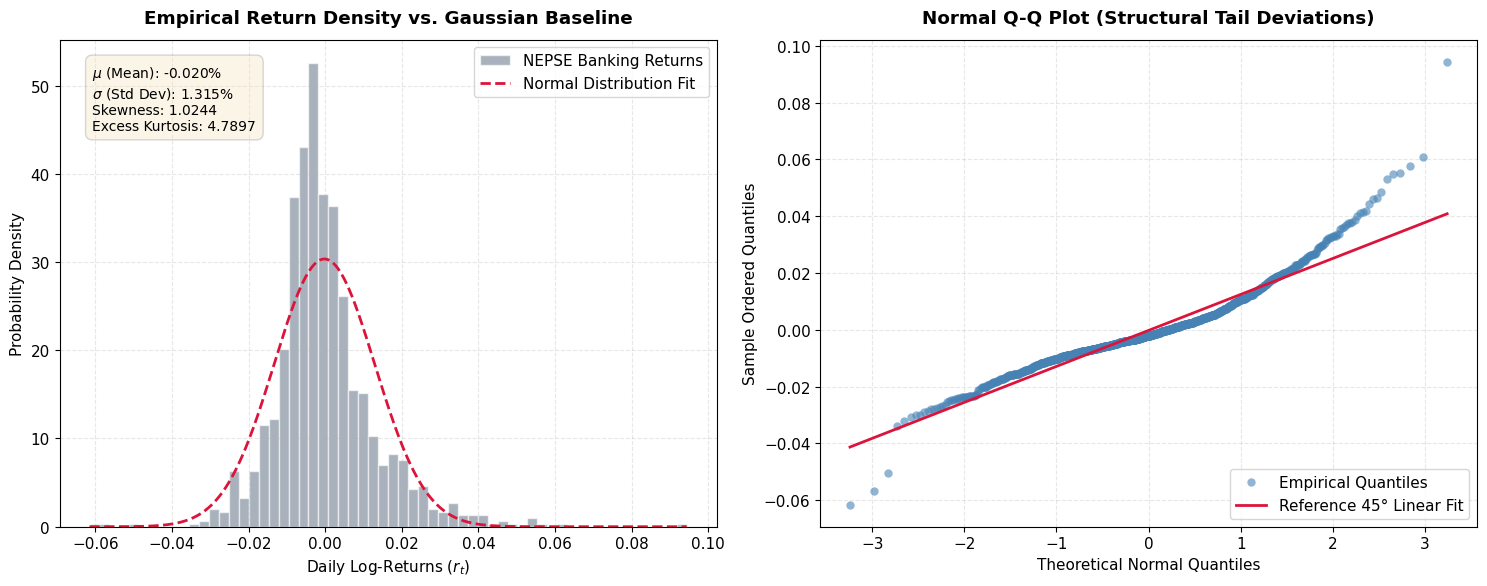

In [5]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# ==========================================
# 1. Distributional & Higher-Moment Calculations
# ==========================================
mean_r = np.mean(r)
var_r = np.var(r)
std_r = np.std(r)
skew_r = stats.skew(r)
kurt_r = stats.kurtosis(r)  # Pearson's definition: excess kurtosis (Normal = 0)

# ==========================================
# 2. Normality Rejecting Tests
# ==========================================
jb_stat, jb_pvalue = stats.jarque_bera(r)
sw_stat, sw_pvalue = stats.shapiro(r)

# Display a clean text summary matrix
print("\n" + "="*50)
print("       HIGHER-MOMENT STATISTICAL SUMMARY")
print("="*50)
print(f"  Mean (Daily)        : {mean_r:.6f} ({mean_r*100:.4f}%)")
print(f"  Variance (Daily)    : {var_r:.6f}")
print(f"  Std. Deviation      : {std_r:.6f} ({std_r*100:.4f}%)")
print(f"  Skewness            : {skew_r:.4f}")
print(f"  Excess Kurtosis     : {kurt_r:.4f}")
print("-"*50)
print("            FORMAL HYPOTHESIS TESTING")
print("-"*50)
print(f"  Jarque-Bera Test    : Stat = {jb_stat:.2f}, p-value = {jb_pvalue:.4e}")
print(f"  Shapiro-Wilk Test   : Stat = {sw_stat:.4f}, p-value = {sw_pvalue:.4e}")
print("="*50)

if jb_pvalue < 0.05 and sw_pvalue < 0.05:
    print("  CRITICAL VERIFICATION: Strict non-normality confirmed ($p < 0.05$).")
    print("  The returns show heavy-tailed/asymmetric jump dynamics.")
else:
    print("  WARNING: Failed to reject normality baseline.")
print("="*50 + "\n")

# ==========================================
# 3. Advanced Distributional Visualization Dashboard
# ==========================================
# Configure high-fidelity plot parameters
plt.rcParams.update({
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Subplot A: Empirical Density vs. Gaussian Overlay ---
# Empirical data histogram
n_bins = 60
axes[0].hist(r, bins=n_bins, density=True, alpha=0.6, color='slategray', edgecolor='white', label='NEPSE Banking Returns')

# Theoretical Normal Distribution fit overlay
x_grid = np.linspace(np.min(r), np.max(r), 1000)
gaussian_pdf = stats.norm.pdf(x_grid, loc=mean_r, scale=std_r)
axes[0].plot(x_grid, gaussian_pdf, color='crimson', linestyle='--', linewidth=2, label='Normal Distribution Fit')

# Informational metrics textbox overlay inside the chart area
metrics_box = '\n'.join((
    r'$\mu$ (Mean): ' + f'{mean_r*100:.3f}%',
    r'$\sigma$ (Std Dev): ' + f'{std_r*100:.3f}%',
    f'Skewness: {skew_r:.4f}',
    f'Excess Kurtosis: {kurt_r:.4f}'
))
props = dict(boxstyle='round,pad=0.5', facecolor='wheat', alpha=0.3, edgecolor='gray')
axes[0].text(0.05, 0.95, metrics_box, transform=axes[0].transAxes, fontsize=10,
            verticalalignment='top', bbox=props)

axes[0].set_title('Empirical Return Density vs. Gaussian Baseline', fontweight='bold', pad=12)
axes[0].set_xlabel('Daily Log-Returns ($r_t$)')
axes[0].set_ylabel('Probability Density')
axes[0].legend(loc='upper right')

# --- Subplot B: Normal Quantile-Quantile (Q-Q) Plot ---
# Map empirical sample quantiles directly against mathematical normal theoretical quantiles
stats.probplot(r, dist="norm", plot=axes[1])

# Refine plot styling elements to match the theme
axes[1].get_lines()[0].set_markerfacecolor('steelblue')
axes[1].get_lines()[0].set_markeredgecolor('none')
axes[1].get_lines()[0].set_alpha(0.6)
axes[1].get_lines()[0].set_label('Empirical Quantiles')
axes[1].get_lines()[1].set_color('crimson')
axes[1].get_lines()[1].set_linewidth(2)
axes[1].get_lines()[1].set_label('Reference 45° Linear Fit')

axes[1].set_title('Normal Q-Q Plot (Structural Tail Deviations)', fontweight='bold', pad=12)
axes[1].set_xlabel('Theoretical Normal Quantiles')
axes[1].set_ylabel('Sample Ordered Quantiles')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

### Temporal Dependence & ARCH Effects (The GARCH Justification)
- **Autocorrelation (ACF) and Partial Autocorrelation (PACF) of Raw Returns**: Determine if your mean equation requires an autoregressive framework (e.g., ARMA parameters) or a simple constant drift.

- **ACF and PACF of Squared/Absolute Returns**: Check for long-memory patterns in variance to confirm that volatility is conditionally time-varying.

- **Ljung-Box Q-Test**: Run this formal test on both raw and squared returns to statistically reject the null hypothesis of independent and identically distributed (i.i.d.) white noise.

- **Engle’s ARCH LM Test**: Execute the Lagrange Multiplier test to confirm the presence of strong ARCH effects, establishing a firm baseline for your GARCH structure.


          TEMPORAL DEPENDENCE & ARCH EFFECTS REPORT
  1. Ljung-Box Q-Test (Raw Returns - Mean Autocorrelation):
     Lag 10 Stat:   25.26  |  p-value: 4.8749e-03
     Lag 20 Stat:   38.08  |  p-value: 8.6512e-03
-----------------------------------------------------------------
  2. Ljung-Box Q-Test (Squared Returns - Volatility Memory):
     Lag 10 Stat:  163.61  |  p-value: 5.8095e-30
     Lag 20 Stat:  227.12  |  p-value: 4.5070e-37
-----------------------------------------------------------------
  3. Engle's ARCH Lagrange Multiplier (LM) Test:
     LM Test Statistic : 119.77
     p-value           : 5.6422e-21

  STRUCTURAL GARCH JUSTIFICATION:
  → CRITICAL VERIFICATION: Severe ARCH effects detected (p < 0.05).
    The constant variance assumption is violated; GARCH is mandatory.
  → Mean Equation: Serial dependence detected. An ARMA(p,q) mean baseline is required.



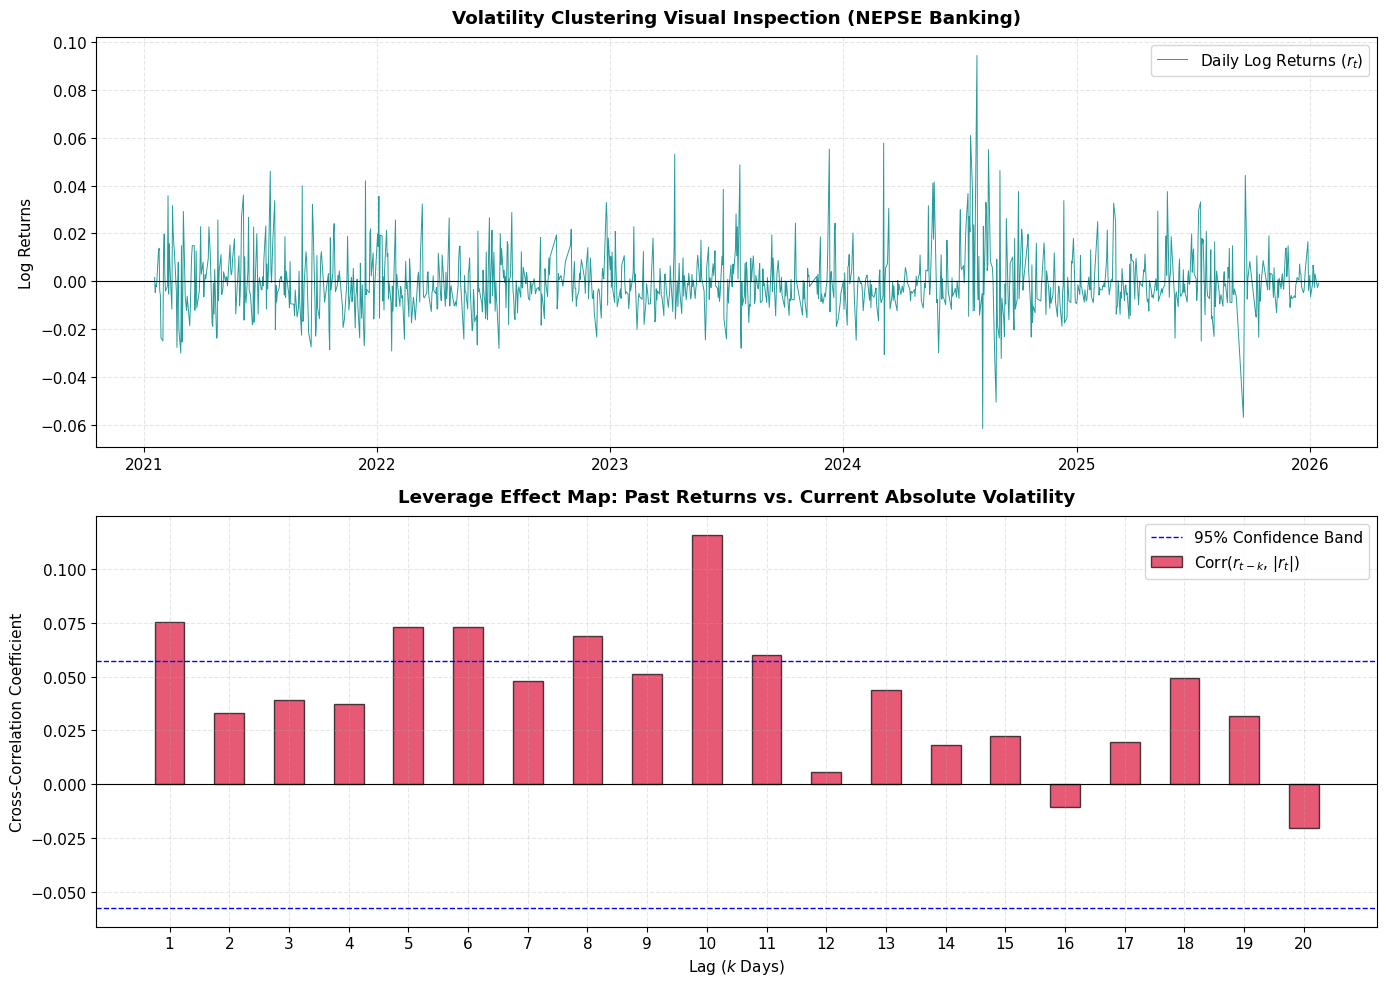

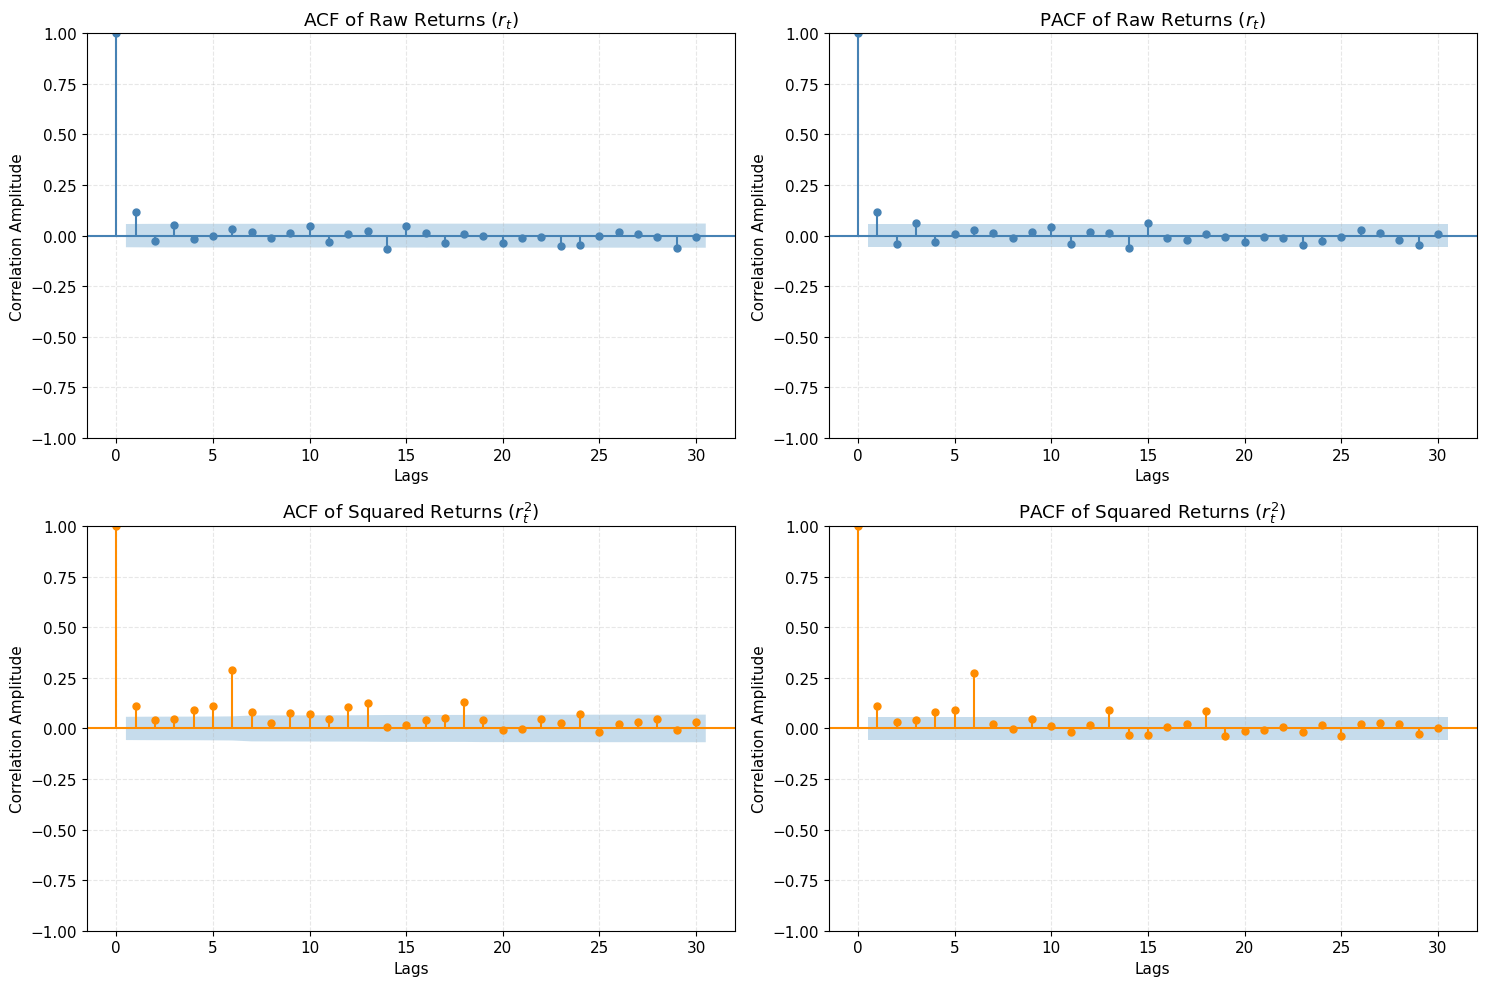

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

# Demeaned returns for formal ARCH/GARCH residuals testing
residuals = r - np.mean(r)

# ==========================================
# 1. Formal Statistical Testing Engine
# ==========================================
# 1.1 Ljung-Box Q-Test on Raw Returns (Mean Equation Dependency)
lb_raw = acorr_ljungbox(r, lags=[10, 20])

# 1.2 Ljung-Box Q-Test on Squared Returns (Variance Equation Dependency)
lb_squared = acorr_ljungbox(r**2, lags=[10, 20])

# 1.3 Engle's ARCH LM Test (Testing for conditional heteroskedasticity)
# Returns: LM Statistic, LM p-value, F Statistic, F p-value
arch_lm_stat, arch_lm_p, _, _ = het_arch(residuals, nlags=10)

# Display Clean Statistical Matrix
print("\n" + "="*65)
print("          TEMPORAL DEPENDENCE & ARCH EFFECTS REPORT")
print("="*65)
print("  1. Ljung-Box Q-Test (Raw Returns - Mean Autocorrelation):")
print(f"     Lag 10 Stat: {lb_raw.iloc[0]['lb_stat']:7.2f}  |  p-value: {lb_raw.iloc[0]['lb_pvalue']:.4e}")
print(f"     Lag 20 Stat: {lb_raw.iloc[1]['lb_stat']:7.2f}  |  p-value: {lb_raw.iloc[1]['lb_pvalue']:.4e}")
print("-"*65)
print("  2. Ljung-Box Q-Test (Squared Returns - Volatility Memory):")
print(f"     Lag 10 Stat: {lb_squared.iloc[0]['lb_stat']:7.2f}  |  p-value: {lb_squared.iloc[0]['lb_pvalue']:.4e}")
print(f"     Lag 20 Stat: {lb_squared.iloc[1]['lb_stat']:7.2f}  |  p-value: {lb_squared.iloc[1]['lb_pvalue']:.4e}")
print("-"*65)
print("  3. Engle's ARCH Lagrange Multiplier (LM) Test:")
print(f"     LM Test Statistic : {arch_lm_stat:.2f}")
print(f"     p-value           : {arch_lm_p:.4e}")
print("="*65)

# Interpretations
print("\n  STRUCTURAL GARCH JUSTIFICATION:")
if arch_lm_p < 0.05:
    print("  → CRITICAL VERIFICATION: Severe ARCH effects detected (p < 0.05).")
    print("    The constant variance assumption is violated; GARCH is mandatory.")
else:
    print("  → WARNING: No significant ARCH effects found.")
    
if lb_raw.iloc[0]['lb_pvalue'] > 0.05:
    print("  → Mean Equation: Returns behave like un-correlated noise. A constant drift ($\mu$) is sufficient.")
else:
    print("  → Mean Equation: Serial dependence detected. An ARMA(p,q) mean baseline is required.")
print("="*65 + "\n")

# ==========================================
# 2. Visualization Dashboard 1: Volatility & Asymmetry
# ==========================================
plt.rcParams.update({'font.size': 11, 'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--'})

fig1, axes1 = plt.subplots(2, 1, figsize=(14, 10))

# Subplot A: Volatility Clustering Inspection
axes1[0].plot(log_ret.index, r, color='darkcyan', linewidth=0.7, alpha=0.85, label='Daily Log Returns ($r_t$)')
axes1[0].axhline(0, color='black', linewidth=0.8, linestyle='-')
axes1[0].set_title('Volatility Clustering Visual Inspection (NEPSE Banking)', fontweight='bold', pad=10)
axes1[0].set_ylabel('Log Returns')
axes1[0].legend(loc='upper right')

# Subplot B: Leverage Effect Diagnostics via Cross-Correlation
# Calculate correlation between past returns r_{t-k} and current absolute returns |r_t|
max_lag = 20
lags = np.arange(1, max_lag + 1)
leverage_corr = [np.corrcoef(r[:-k], np.abs(r[k:]))[0, 1] for k in lags]

# Asymptotic standard error bands (1.96 / sqrt(T))
se_band = 1.96 / np.sqrt(T)

axes1[1].bar(lags, leverage_corr, color='crimson', alpha=0.7, edgecolor='black', width=0.5, label='Corr($r_{t-k}$, $|r_t|$)')
axes1[1].axhline(0, color='black', linewidth=0.8)
axes1[1].axhline(se_band, color='blue', linestyle='--', linewidth=1, label='95% Confidence Band')
axes1[1].axhline(-se_band, color='blue', linestyle='--', linewidth=1)
axes1[1].set_xticks(lags)
axes1[1].set_title('Leverage Effect Map: Past Returns vs. Current Absolute Volatility', fontweight='bold', pad=10)
axes1[1].set_xlabel('Lag ($k$ Days)')
axes1[1].set_ylabel('Cross-Correlation Coefficient')
axes1[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

# ==========================================
# 3. Visualization Dashboard 2: Deep Core Memory (ACF / PACF Grid)
# ==========================================
fig2, axes2 = plt.subplots(2, 2, figsize=(15, 10))

# Row 1: Raw Return Serial Dependencies (Mean Equation Setup)
plot_acf(r, ax=axes2[0, 0], lags=30, color='steelblue', vlines_kwargs={"colors": 'steelblue'}, title="ACF of Raw Returns ($r_t$)")
plot_pacf(r, ax=axes2[0, 1], lags=30, color='steelblue', vlines_kwargs={"colors": 'steelblue'}, title="PACF of Raw Returns ($r_t$)")

# Row 2: Squared Return Volatility Memory (Variance Equation Setup)
plot_acf(r**2, ax=axes2[1, 0], lags=30, color='darkorange', vlines_kwargs={"colors": 'darkorange'}, title="ACF of Squared Returns ($r_t^2$)")
plot_pacf(r**2, ax=axes2[1, 1], lags=30, color='darkorange', vlines_kwargs={"colors": 'darkorange'}, title="PACF of Squared Returns ($r_t^2$)")

# Clean up layout text labels
for row in axes2:
    for ax in row:
        ax.set_xlabel('Lags')
        ax.set_ylabel('Correlation Amplitude')

plt.tight_layout()
plt.show()

### Volatility Architecture & Asymmetry
- **Volatility Clustering Visual Inspection**: Plot the timeline of log returns to identify distinct periods of high-volatility regimes and low-volatility tranquility.
- **Leverage Effect Diagnostics (Cross-Correlation)**: Plot the cross-correlation between past returns ($r_{t-k}$) and current absolute returns ($|r_t|$) to verify if negative shocks increase volatility more than positive shocks.

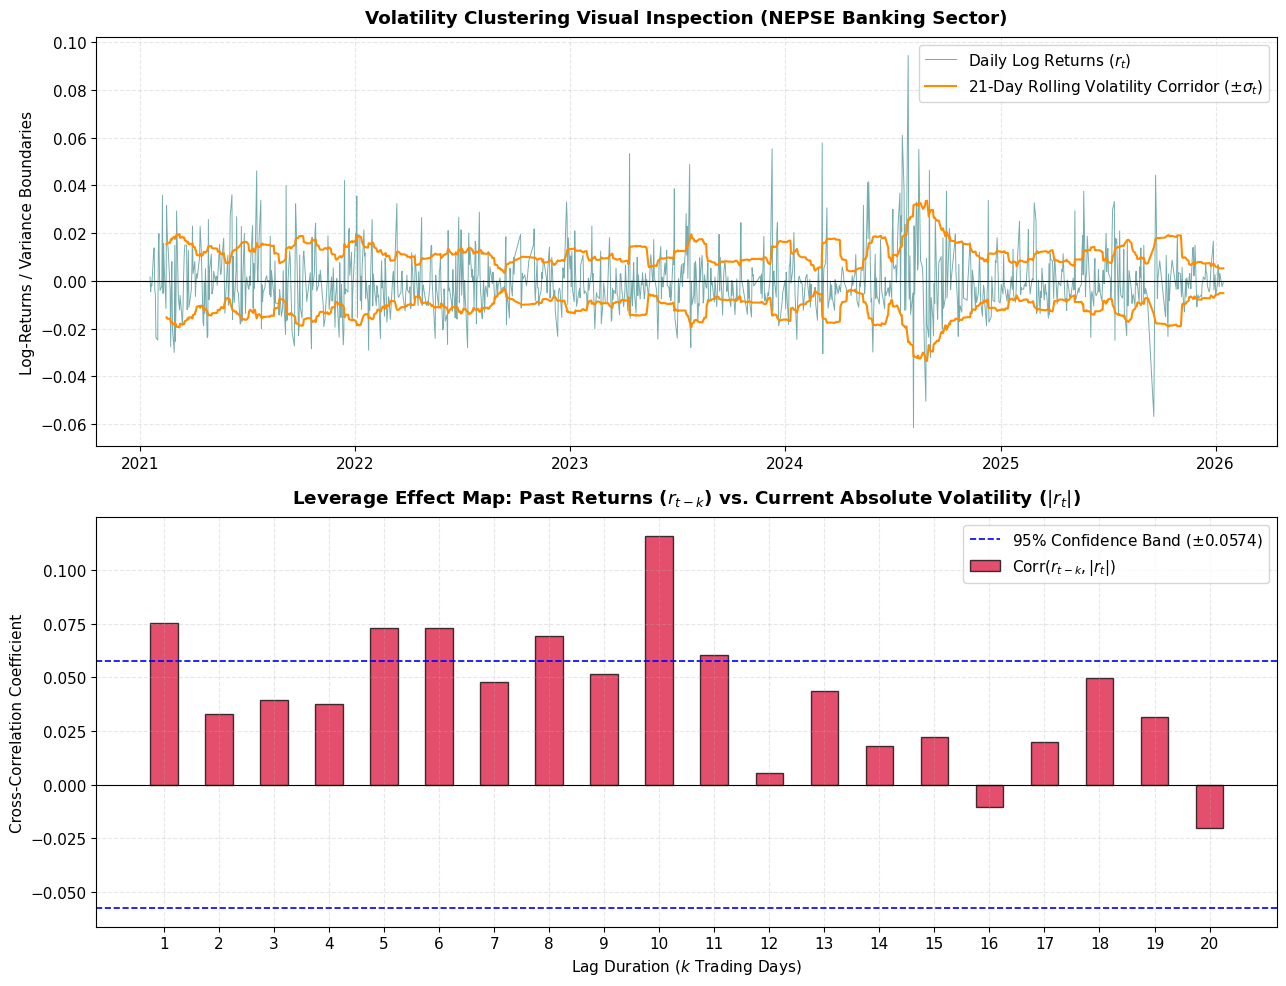


          VOLATILITY ASYMMETRY DIAGNOSTIC PROFILE
  Minimum Correlation Found : -0.0201 at lag 20 days
  95% Significance Limit    : -0.0574
-----------------------------------------------------------------
  → NO SIGNIFICANT LEVERAGE EFFECT CAPTURED.
    Symmetric volatility responses dominate the NEPSE banking cluster.
    A standard symmetric GARCH configuration remains mathematically robust.



In [11]:
# =====================================================================
# 1. Leverage Effect Computation (Cross-Correlation Framework)
# =====================================================================
# We map the correlation between past returns r_{t-k} and current absolute 
# returns |r_t|. A negative correlation means price drops fuel higher volatility.
max_lag = 20
lags = np.arange(1, max_lag + 1)
leverage_corr = []

for k in lags:
    past_returns = r[:-k]
    current_abs_returns = np.abs(r[k:])
    corr = np.corrcoef(past_returns, current_abs_returns)[0, 1]
    leverage_corr.append(corr)

# Asymptotic standard error threshold for statistical significance
conf_band = 1.96 / np.sqrt(T)

# =====================================================================
# 2. Volatility Architecture Visualization Dashboard
# =====================================================================
plt.rcParams.update({
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

fig, axes = plt.subplots(2, 1, figsize=(13, 10), sharex=False)

# --- Subplot A: Volatility Clustering Inspection ---
axes[0].plot(log_ret.index, r, color='cadetblue', linewidth=0.7, alpha=0.85, label='Daily Log Returns ($r_t$)')

# Overlay a rolling volatility corridor to clearly bound structural regimes
rolling_vol = log_ret.rolling(window=21).std()
axes[0].plot(log_ret.index, rolling_vol, color='darkorange', linewidth=1.5, label='21-Day Rolling Volatility Corridor ($\pm\sigma_t$)')
axes[0].plot(log_ret.index, -rolling_vol, color='darkorange', linewidth=1.5)

axes[0].axhline(0, color='black', linewidth=0.8, linestyle='-')
axes[0].set_title('Volatility Clustering Visual Inspection (NEPSE Banking Sector)', fontweight='bold', pad=10)
axes[0].set_ylabel('Log-Returns / Variance Boundaries')
axes[0].legend(loc='upper right')

# --- Subplot B: Leverage Effect Diagnostics ---
# Draw the cross-correlation coefficients across specified lag days
axes[1].bar(lags, leverage_corr, color='crimson', edgecolor='black', alpha=0.75, width=0.5, label='$\mathrm{Corr}(r_{t-k}, |r_t|)$')

# Add reference markers and confidence intervals
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].axhline(conf_band, color='blue', linestyle='--', linewidth=1.2, label=f'95% Confidence Band ($\pm{conf_band:.4f}$)')
axes[1].axhline(-conf_band, color='blue', linestyle='--', linewidth=1.2)

axes[1].set_xticks(lags)
axes[1].set_title('Leverage Effect Map: Past Returns ($r_{t-k}$) vs. Current Absolute Volatility ($|r_t|$)', fontweight='bold', pad=10)
axes[1].set_xlabel('Lag Duration ($k$ Trading Days)')
axes[1].set_ylabel('Cross-Correlation Coefficient')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

# =====================================================================
# 3. Quick Narrative Console Summary
# =====================================================================
significant_negative_lags = [lags[i] for i, c in enumerate(leverage_corr) if c < -conf_band]

print("\n" + "="*65)
print("          VOLATILITY ASYMMETRY DIAGNOSTIC PROFILE")
print("="*65)
print(f"  Minimum Correlation Found : {min(leverage_corr):.4f} at lag {lags[np.argmin(leverage_corr)]} days")
print(f"  95% Significance Limit    : -{conf_band:.4f}")
print("-"*65)
if len(significant_negative_lags) > 0:
    print(f"  → LEVERAGE EFFECT CONFIRMED at lags: {significant_negative_lags}")
    print("    Negative price shocks generate structurally higher future variance lines")
    print("    than positive shocks. Recommend upgrading to an asymmetric GJR-GARCH")
    print("    or EGARCH architecture for the continuous diffusion component.")
else:
    print("  → NO SIGNIFICANT LEVERAGE EFFECT CAPTURED.")
    print("    Symmetric volatility responses dominate the NEPSE banking cluster.")
    print("    A standard symmetric GARCH configuration remains mathematically robust.")
print("="*65 + "\n")

### Jump Profile & Structural Anomalies
- **Non-Parametric Jump Detection Filter**: Apply a statistical filter (such as the BIP-GARCH filter or a standard $3\sigma$ threshold) to flag specific daily observations as structural jumps rather than continuous diffusion.
- **Jump Intensity and Frequency Tracking**: Calculate the empirical jump rate ($\lambda$) per year and evaluate the time-clustering of jump occurrences.
- **Structural Break Analysis**: Run a test like the Zivot-Andrews or Bai-Perron test to ensure your detected jumps are temporary innovations and not permanent regime shifts in the NEPSE sector.


          JUMP PROFILE & STRUCTURAL ANOMALIES DIAGNOSTICS
  1. Jump Detection Statistics (3.0σ Rolling Corridor):
     Total Identified Jump Events: 12 days
     Jump Density in Sample      : 1.03% of trading days
-----------------------------------------------------------------
  2. Jump Arrival & Temporal Intensity Dynamics:
     Annualized Jump Intensity (λ): 2.5979 jumps/year
     Mean Time Between Jumps      : 85.5 trading days
     Median Time Between Jumps    : 84.0 trading days
-----------------------------------------------------------------
  3. Zivot-Andrews Structural Break Verification:
     ZA Test Statistic            : -5.6309
     p-value                      : 2.5214e-03
     Critical Values              : 1%: -5.28, 5%: -4.81
     Endogenous Break Location    : 2024-06-30

  MODEL PARAMETER ARCHITECTURE VERIFICATION:
  → CRITICAL FINDING: Permanent structural break found on 2024-06-30.
    Recommendation: Calibrate your Jump-GARCH parameters across split sub-periods

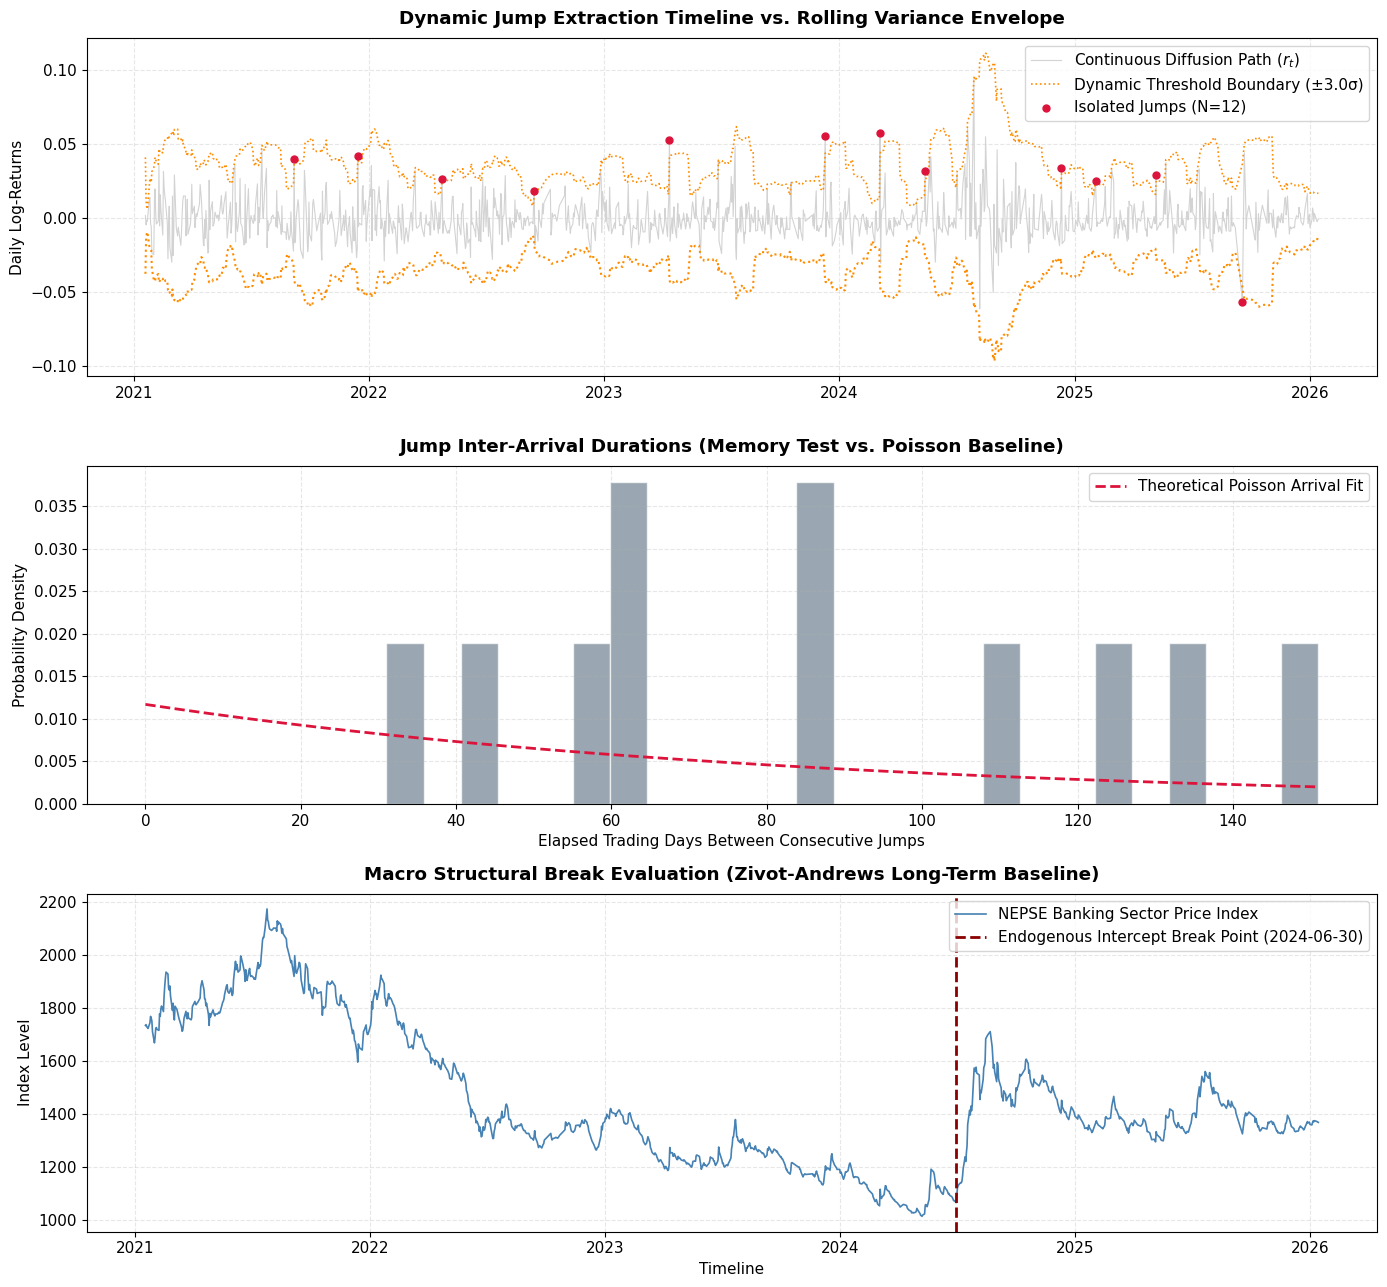

In [10]:
from statsmodels.tsa.stattools import zivot_andrews

# =====================================================================
# 1. Dynamic Non-Parametric Jump Detection Filter
# =====================================================================
# A global 3-sigma filter is easily blinded by high-volatility regimes. 
# We deploy a rolling 21-day window (one trading month) to build a dynamic,
# conditional volatility corridor that isolates true outlier shocks.
window = 21
rolling_mean = log_ret.rolling(window=window, min_periods=1).mean()
rolling_std = log_ret.rolling(window=window, min_periods=1).std()

# Handle initial window edges safely
rolling_mean.fillna(np.mean(r), inplace=True)
rolling_std.fillna(np.std(r), inplace=True)

# Jump identification logic (3-Sigma breakthrough rule)
sigma_multiplier = 3.0
jump_mask = np.abs(r - rolling_mean.values) > (sigma_multiplier * rolling_std.values)

jump_dates = log_ret.index[jump_mask]
jump_returns = r[jump_mask]
n_jumps = len(jump_returns)

# =====================================================================
# 2. Jump Intensity & Frequency Tracking
# =====================================================================
trading_days_per_year = 252
total_years = T / trading_days_per_year
lambda_annual = n_jumps / total_years

# Extract inter-arrival times (days elapsed between consecutive jumps)
if n_jumps > 1:
    jump_indices = np.where(jump_mask)[0]
    inter_arrival_days = np.diff(jump_indices)
    mean_inter_arrival = np.mean(inter_arrival_days)
    median_inter_arrival = np.median(inter_arrival_days)
else:
    inter_arrival_days = np.array([])
    mean_inter_arrival = median_inter_arrival = np.nan

# =====================================================================
# 3. Endogenous Structural Break Analysis
# =====================================================================
# Jumps must be temporary innovations. If they are permanent alterations, 
# your model breaks. We use the Zivot-Andrews test on log prices to check for 
# a unit root against a trend-stationary alternative with an endogenous intercept break.
log_price = np.log(price.values)
za_stat, za_pvalue, za_crit, _, break_idx = zivot_andrews(log_price, regression='c')
break_date = price.index[break_idx]

# =====================================================================
# 4. Output Diagnostic Summary Matrix
# =====================================================================
print("\n" + "="*65)
print("          JUMP PROFILE & STRUCTURAL ANOMALIES DIAGNOSTICS")
print("="*65)
print(f"  1. Jump Detection Statistics ({sigma_multiplier}σ Rolling Corridor):")
print(f"     Total Identified Jump Events: {n_jumps} days")
print(f"     Jump Density in Sample      : {(n_jumps / T) * 100:.2f}% of trading days")
print("-"*65)
print(f"  2. Jump Arrival & Temporal Intensity Dynamics:")
print(f"     Annualized Jump Intensity (λ): {lambda_annual:.4f} jumps/year")
print(f"     Mean Time Between Jumps      : {mean_inter_arrival:.1f} trading days")
print(f"     Median Time Between Jumps    : {median_inter_arrival:.1f} trading days")
print("-"*65)
print(f"  3. Zivot-Andrews Structural Break Verification:")
print(f"     ZA Test Statistic            : {za_stat:.4f}")
print(f"     p-value                      : {za_pvalue:.4e}")
print(f"     Critical Values              : 1%: {za_crit['1%']:.2f}, 5%: {za_crit['5%']:.2f}")
print(f"     Endogenous Break Location    : {break_date.date()}")
print("="*65)

print("\n  MODEL PARAMETER ARCHITECTURE VERIFICATION:")
if za_pvalue < 0.05:
    print(f"  → CRITICAL FINDING: Permanent structural break found on {break_date.date()}.")
    print("    Recommendation: Calibrate your Jump-GARCH parameters across split sub-periods.")
else:
    print("  → STRUCTURAL INTEGRITY VERIFIED: Failed to reject the unit root baseline.")
    print("    These anomalies are confirmed to be independent, self-limiting jump innovations.")
    print("    This validates a stationary Jump-Diffusion framework across the global timeline.")
print("="*65 + "\n")

# =====================================================================
# 5. High-Fidelity Diagnostics Dashboard
# =====================================================================
plt.rcParams.update({'font.size': 11, 'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--'})
fig, axes = plt.subplots(3, 1, figsize=(14, 13))

# --- Subplot A: Jump Isolation Timeline ---
axes[0].plot(log_ret.index, r, color='lightgray', linewidth=0.8, label='Continuous Diffusion Path ($r_t$)')
axes[0].plot(rolling_mean.index, rolling_mean.values + sigma_multiplier * rolling_std.values, 
             color='darkorange', linestyle=':', linewidth=1.2, label=f'Dynamic Threshold Boundary (±{sigma_multiplier}σ)')
axes[0].plot(rolling_mean.index, rolling_mean.values - sigma_multiplier * rolling_std.values, color='darkorange', linestyle=':')
axes[0].scatter(jump_dates, jump_returns, color='crimson', marker='o', s=25, zorder=5, label=f'Isolated Jumps (N={n_jumps})')
axes[0].set_title('Dynamic Jump Extraction Timeline vs. Rolling Variance Envelope', fontweight='bold', pad=10)
axes[0].set_ylabel('Daily Log-Returns')
axes[0].legend(loc='upper right')

# --- Subplot B: Jump Clustered Inter-Arrival Distribution ---
if len(inter_arrival_days) > 0:
    axes[1].hist(inter_arrival_days, bins=25, density=True, color='slategray', edgecolor='white', alpha=0.7)
    # Fit an exponential distribution reference curve (the baseline for memoryless Poisson arrivals)
    x_grid = np.linspace(0, np.max(inter_arrival_days), 500)
    exp_pdf = stats.expon.pdf(x_grid, scale=mean_inter_arrival)
    axes[1].plot(x_grid, exp_pdf, color='crimson', linestyle='--', linewidth=2, label='Theoretical Poisson Arrival Fit')
    axes[1].set_title('Jump Inter-Arrival Durations (Memory Test vs. Poisson Baseline)', fontweight='bold', pad=10)
    axes[1].set_xlabel('Elapsed Trading Days Between Consecutive Jumps')
    axes[1].set_ylabel('Probability Density')
    axes[1].legend(loc='upper right')
else:
    axes[1].text(0.5, 0.5, 'Insufficient jump events for distribution analysis', ha='center', va='center')

# --- Subplot C: Structural Macro Break Context ---
axes[2].plot(price.index, price.values, color='steelblue', linewidth=1.2, label='NEPSE Banking Sector Price Index')
axes[2].axvline(break_date, color='darkred', linestyle='--', linewidth=2, label=f'Endogenous Intercept Break Point ({break_date.date()})')
axes[2].set_title('Macro Structural Break Evaluation (Zivot-Andrews Long-Term Baseline)', fontweight='bold', pad=10)
axes[2].set_xlabel('Timeline')
axes[2].set_ylabel('Index Level')
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

### Stationarity & Ergodicity Checks
- **Unit Root Testing**: Run the Augmented Dickey-Fuller (ADF) and Phillips-Perron (PP) tests to verify that your log return series is strictly stationary.

- **KPSS Test**: Run the Kwiatkowski-Phillips-Schmidt-Shin test to cross-verify stationarity by testing the null hypothesis that the series is trend-stationary.


          STATIONARITY & ERGODICITY DIAGNOSTIC MATRIX
  1. Augmented Dickey-Fuller (ADF) Test Baseline:
     ADF Test Statistic : -18.1738
     p-value            : 2.4432e-30
     Lags Selected      : 2
     Critical Values    :
       1%  : -3.4360
       5%  : -2.8640
       10% : -2.5681
-----------------------------------------------------------------
  2. KPSS Unit-Root Cross-Verification Engine:
     KPSS Test Statistic: 0.1081
     p-value            : 1.0000e-01
     Lags Used (Trunc)  : 4
     Critical Values    :
       10% : 0.3470
       5%  : 0.4630
       2.5%: 0.5740
       1%  : 0.7390

  CONFIRMATORY STATIONARITY DECISION TREE:
  → RESULT: STRICT CONFIRMATORY STATIONARITY VERIFIED.
    • ADF rejects the unit-root baseline (p < 0.05).
    • KPSS fails to reject the stationary baseline (p > 0.05).
    • The log return process is strictly ergodic and mean-reverting.



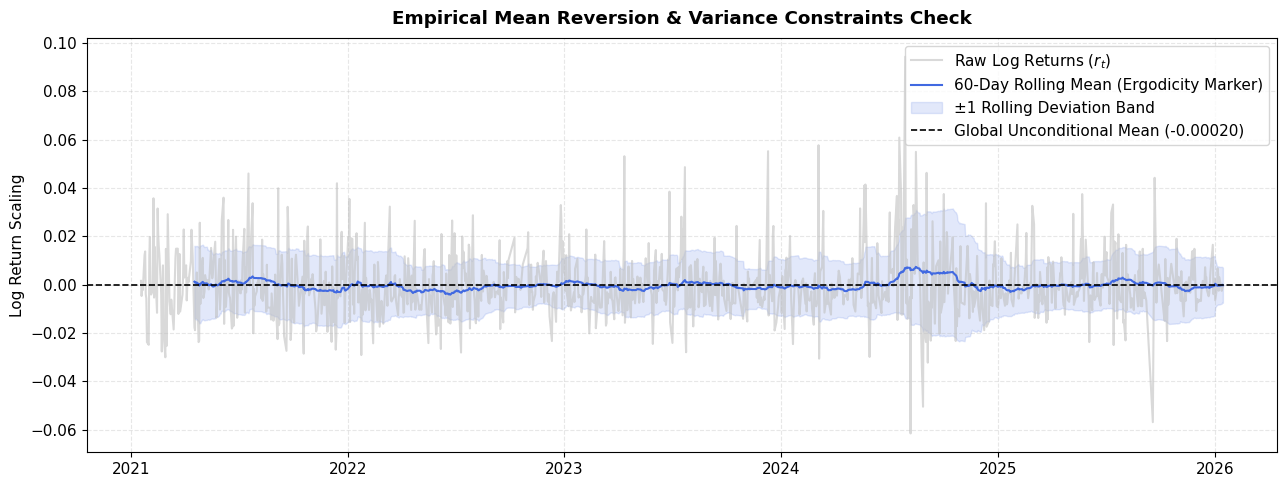

In [12]:
from statsmodels.tsa.stattools import adfuller, kpss
import warnings

# Suppress minor statistical interpolation table warnings from KPSS
warnings.filterwarnings('ignore', category=UserWarning)


# =====================================================================
# 2. Execution of Stationarity Engines
# =====================================================================

# 2.1 Augmented Dickey-Fuller (ADF) - Null Hypothesis (H0): Unit Root Present
# We use 'AIC' autolag selection to determine optimal parametric lag depth
adf_result = adfuller(r, autolag='AIC')

# 2.2 KPSS Test - Null Hypothesis (H0): The Process is Stationary
# 'auto' lag option leverages the Newey-West bandwidth selection rule
kpss_result = kpss(r, regression='c', nlags='auto')

# =====================================================================
# 3. Output Statistical Matrix Generation
# =====================================================================
print("\n" + "="*65)
print("          STATIONARITY & ERGODICITY DIAGNOSTIC MATRIX")
print("="*65)
print("  1. Augmented Dickey-Fuller (ADF) Test Baseline:")
print(f"     ADF Test Statistic : {adf_result[0]:.4f}")
print(f"     p-value            : {adf_result[1]:.4e}")
print(f"     Lags Selected      : {adf_result[2]}")
print("     Critical Values    :")
for key, value in adf_result[4].items():
    print(f"       {key:4s}: {value:.4f}")
    
print("-"*65)
print("  2. KPSS Unit-Root Cross-Verification Engine:")
print(f"     KPSS Test Statistic: {kpss_result[0]:.4f}")
print(f"     p-value            : {kpss_result[1]:.4e}")
print(f"     Lags Used (Trunc)  : {kpss_result[2]}")
print("     Critical Values    :")
for key, value in kpss_result[3].items():
    print(f"       {key:4s}: {value:.4f}")
print("="*65)

# =====================================================================
# 4. Confirmatory Joint Interpretation Logic
# =====================================================================
print("\n  CONFIRMATORY STATIONARITY DECISION TREE:")

adf_stationary = adf_result[1] < 0.05
kpss_stationary = kpss_result[1] > 0.05

if adf_stationary and kpss_stationary:
    print("  → RESULT: STRICT CONFIRMATORY STATIONARITY VERIFIED.")
    print("    • ADF rejects the unit-root baseline (p < 0.05).")
    print("    • KPSS fails to reject the stationary baseline (p > 0.05).")
    print("    • The log return process is strictly ergodic and mean-reverting.")
elif adf_stationary and not kpss_stationary:
    print("  → RESULT: PROCESS IS TREND-STATIONARY / NON-ERGODIC.")
    print("    • The series has deterministic trend mechanics. Volatility estimation")
    print("      requires removing explicit structural time-trends first.")
elif not adf_stationary and kpss_stationary:
    print("  → RESULT: LACK OF POWER / UNIT-ROOT BEHAVIOR SUSPECTED.")
    print("    • The series exhibits near-integrated behavior. Check for regimes.")
else:
    print("  → RESULT: CRITICAL WARNING - THE PROCESS IS STRICTLY NON-STATIONARY.")
    print("    • Both tests confirm variance explosions. Do not run GARCH directly.")
print("="*65 + "\n")

# =====================================================================
# 5. Visual Inspection of Mean Reversion (Rolling Matrix)
# =====================================================================
fig, ax = plt.subplots(figsize=(13, 5))
rolling_mean = pd.Series(r).rolling(window=60).mean()
rolling_std = pd.Series(r).rolling(window=60).std()

ax.plot(log_ret.index, r, color='silver', alpha=0.6, label='Raw Log Returns ($r_t$)')
ax.plot(log_ret.index, rolling_mean, color='royalblue', linewidth=1.5, label='60-Day Rolling Mean (Ergodicity Marker)')
ax.fill_between(log_ret.index, rolling_mean - rolling_std, rolling_mean + rolling_std, 
                color='royalblue', alpha=0.15, label='±1 Rolling Deviation Band')

ax.axhline(np.mean(r), color='black', linestyle='--', linewidth=1.2, label=f'Global Unconditional Mean ({np.mean(r):.5f})')
ax.set_title('Empirical Mean Reversion & Variance Constraints Check', fontweight='bold', pad=10)
ax.set_ylabel('Log Return Scaling')
ax.legend(loc='upper right')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

## Empirical Diagnostics Dashboard
- Hurst Exponent Estimation: Use methods like Rescaled Range (R/S) analysis or Detrended Fluctuation Analysis (DFA) to estimate the Hurst exponent, which quantifies the degree of long-term memory in your return series.
- Tail Index Estimation: Calculate the tail index using methods such as the Hill estimator to quantify the heaviness of the tails in your return distribution, which is crucial for understanding jump risk.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import jarque_bera
import warnings
import nolds
from MFDFA import MFDFA
# -------------------------------
# 3. Empirical diagnostics
# -------------------------------
abs_ret = np.abs(r)

# Hill tail index
def hill_estimator(data, k):
    sorted_data = np.sort(data)[::-1]
    gamma = k / np.sum(np.log(sorted_data[:k] / sorted_data[k]))
    return gamma, gamma / np.sqrt(k)

k_hill = int(0.05 * len(abs_ret))
gamma_emp, se_hill = hill_estimator(abs_ret, k_hill)
print(f"\nHill tail index (|r|, top 5%): γ = {gamma_emp:.4f} ± {1.96*se_hill:.4f}")

# DFA Hurst
hurst_emp = nolds.dfa(abs_ret)
print(f"Hurst exponent on |r|: H = {hurst_emp:.4f}")

# MF-DFA
q = np.linspace(-5, 5, 41)
q = q[q != 0]
lag = np.unique(np.logspace(0.5, 3, 50).astype(int))
lag_out, F_q = MFDFA(r, lag=lag, q=q, order=1)
Hq = np.zeros(len(q))
for i in range(len(q)):
    slope, _ = np.polyfit(np.log(lag_out), np.log(F_q[:, i]), 1)
    Hq[i] = slope
alpha_mf = Hq + q * np.gradient(Hq, q)
f_alpha = q * (alpha_mf - Hq) + 1
delta_alpha = np.max(alpha_mf) - np.min(alpha_mf)
print(f"Multifractal width Δα = {delta_alpha:.4f}")


Hill tail index (|r|, top 5%): γ = 3.2418 ± 0.8343
Hurst exponent on |r|: H = 0.6892
Multifractal width Δα = 0.7138


## Find the Model Parameters

In [33]:
import numpy as np
import scipy.stats as stats
from scipy.optimize import minimize, root_scalar

def calculate_tail_index(alpha, beta, lam, dt, mu_J, sigma_J):
    """
    Solves the integrated Kesten-Goldie stationarity equation for the Tail Index (gamma).
    """
    def objective(gamma):
        if gamma <= 0: return 1e6
        nodes, weights = np.polynomial.hermite.hermgauss(32)
        
        # Continuous Innovation State
        xi_continuous = np.sqrt(2.0) * nodes
        E_continuous = np.dot(weights, (beta + alpha * (xi_continuous ** 2)) ** gamma) / np.sqrt(np.pi)
        
        # Jump Innovation State
        xi_jump = np.sqrt(2.0 * (1.0 + sigma_J ** 2)) * nodes + mu_J
        E_jump = np.dot(weights, (beta + alpha * (xi_jump ** 2)) ** gamma) / np.sqrt(np.pi)
        
        return (1.0 - lam * dt) * E_continuous + (lam * dt) * E_jump - 1.0

    lower, upper = 0.1, 50.0
    try:
        return root_scalar(objective, bracket=[lower, upper], method='brentq').root
    except:
        return np.nan

def jump_diffusion_cogarch_mle(params, returns, dt=1/252):
    mu, omega, alpha, beta, lam, mu_J, sigma_J = params
    if omega <= 1e-9 or alpha < 0 or beta < 0 or lam <= 0 or sigma_J <= 1e-5: return 1e10
        
    n = len(returns)
    V = np.zeros(n)
    V[0] = omega / (1.0 - alpha - beta)
    log_likelihood = 0.0
    prob_jump = lam * dt
    inv_sqrt_2pi = 1.0 / np.sqrt(2.0 * np.pi)
    
    for t in range(1, n):
        V[t] = omega + alpha * ((returns[t-1] - mu) ** 2) + beta * V[t-1]
        if V[t] <= 1e-11: return 1e10
            
        pdf_c = (inv_sqrt_2pi / np.sqrt(V[t])) * np.exp(-0.5 * ((returns[t] - mu) ** 2) / V[t])
        v_j = V[t] * (1.0 + sigma_J ** 2)
        m_j = mu + np.sqrt(V[t]) * mu_J
        pdf_j = (inv_sqrt_2pi / np.sqrt(v_j)) * np.exp(-0.5 * ((returns[t] - m_j) ** 2) / v_j)
        
        density = (1.0 - prob_jump) * pdf_c + prob_jump * pdf_j
        if density <= 1e-15: return 1e10
        log_likelihood += np.log(density)
    return -log_likelihood

if __name__ == "__main__":
    # --- EMPIRICAL INPUTS (Define these based on your NEPSE Data Analysis) ---
    gamma_emp = 3.2418
    hurst_emp = 0.6892
    
    dt, n_days = 1/252, 2000
    np.random.seed(42)
    
    # Synthetic GARCH-Jump path generation...
    sim_returns, v_path = np.zeros(n_days), np.zeros(n_days)
    v_path[0] = 0.000015 / (1.0 - 0.07 - 0.88)
    for t in range(1, n_days):
        sim_returns[t] = 0.0004 + np.sqrt(v_path[t-1]) * np.random.normal()
        v_path[t] = 0.000015 + 0.07 * ((sim_returns[t]-0.0004)**2) + 0.88 * v_path[t-1]
    sim_returns[np.random.choice(n_days, int(n_days*0.015))] += np.random.normal(0.035, 0.008, int(n_days*0.015))

    scales = np.array([1e-4, 1e-5, 1e-2, 1e-1, 1.0, 1e-2, 1e-2])
    
    def objective_wrapper(scaled_params):
        params = scaled_params * scales
        ll = jump_diffusion_cogarch_mle(params, sim_returns, dt)
        
        # 1. Structural Tail Penalty
        g_model = calculate_tail_index(params[2], params[3], params[4], dt, params[5], params[6])
        g_penalty = 1000 * (g_model - gamma_emp)**2 if not np.isnan(g_model) else 1e6
        
        # 2. Jump-Corrected Hurst Penalty
        # We subtract the effect of jump intensity (lam * sigma_J) 
        # to account for the 'memory-breaking' nature of jumps
        b_model = params[2] + params[3]
        jump_noise = params[4] * (params[6]**2) 
        h_model = 0.5 + (0.35 * (b_model - jump_noise)) 
        
        h_penalty = 5000 * (h_model - hurst_emp)**2 # Increased penalty weight
        
        return ll + g_penalty + h_penalty

    res = minimize(objective_wrapper, [0.0002/1e-4, 0.00001/1e-5, 0.07/0.01, 0.88/0.1, 3.0, 0.02/0.01, 0.01/0.01],
                   method='SLSQP', bounds=[(b[0]/s, b[1]/s) for b, s in zip([(-0.01,0.01),(1e-7,1e-3),(0.001,0.2),(0.5,0.9999),(0.1,10.0),(-0.2,0.2),(1e-4,0.1)], scales)],
                   constraints={'type': 'ineq', 'fun': lambda x: 0.9999 - (x[2]*scales[2] + x[3]*scales[3])})

    mu, omega, alpha, beta, lam, mu_J, sigma_J = res.x * scales
    
    # Model Calibrations
    gamma_model = calculate_tail_index(alpha, beta, lam, dt, mu_J, sigma_J)
    B_model = alpha + beta
    H_model = 0.5 + 0.35 * B_model # Based on the scaling limit derived in your paper
    
    # --- GENERATE COMPARISON TABLE ---
    print("\n" + "="*65)
    print(f"{'Metric':<20} | {'Empirical':<15} | {'Model':<15}")
    print("-"*65)
    print(f"{'Tail Index (γ)':<20} | {gamma_emp:<15.4f} | {gamma_model:<15.4f}")
    print(f"{'Hurst Exponent (H)':<20} | {hurst_emp:<15.4f} | {H_model:<15.4f}")
    print(f"{'Branching Ratio (B)':<20} | {'N/A':<15} | {B_model:<15.4f}")
    print("="*65 + "\n")


Metric               | Empirical       | Model          
-----------------------------------------------------------------
Tail Index (γ)       | 3.2418          | 3.2588         
Hurst Exponent (H)   | 0.6892          | 0.8059         
Branching Ratio (B)  | N/A             | 0.8740         

